# 05 - Conjugate models for counts and proportions

**Goal.** Derive the two workhorse conjugate models for discrete data, beta-binomial
for proportions and Poisson-gamma for counts, and use them on real questions: an A/B
test comparing two conversion rates, and a rate of events per day. Along the way we
find that the posterior mean is a weighted average of the prior mean and the data,
and that a prior can be read as a number of imaginary observations.

## 1. Conjugacy

A family of priors is **conjugate** to a likelihood if the posterior is in the same
family as the prior [1]. Then Bayes' theorem reduces to updating a few numbers (the
prior's parameters, called **hyperparameters**), and every posterior quantity has a
formula or a one-line scipy call.

The trick for finding the posterior is the proportionality of chapter 04: write
likelihood times prior, drop everything that does not involve $\theta$, and
recognise what is left as the kernel of a known density.

## 2. The beta-binomial model

**Model.** $y$ successes in $n$ independent trials with success probability
$\theta$, and a Beta prior:
$$ y\mid\theta\sim \text{Binomial}(n,\theta), \qquad \theta\sim\text{Beta}(\alpha,\beta). $$

**Posterior.** Multiply and keep only what involves $\theta$:
$$ p(\theta\mid y) \;\propto\; \underbrace{\theta^{y}(1-\theta)^{n-y}}_{\text{likelihood}}\;
   \underbrace{\theta^{\alpha-1}(1-\theta)^{\beta-1}}_{\text{prior}}
   = \theta^{\alpha+y-1}(1-\theta)^{\beta+n-y-1}. $$
That is the kernel of a Beta density, so
$$ \boxed{\;\theta\mid y \sim \text{Beta}(\alpha+y,\ \beta+n-y)\;} $$
The update rule is: **add the successes to $\alpha$ and the failures to $\beta$**.
The flat prior of chapter 04 is Beta$(1,1)$, and the shooter's posterior was
Beta$(14, 8)$ all along.

**Reading the prior as data.** Beta$(\alpha,\beta)$ behaves like having already seen
$\alpha$ successes and $\beta$ failures, so $\alpha+\beta$ is the prior's **effective
sample size**. The posterior mean makes this precise:
$$ \mathbb E[\theta\mid y] = \frac{\alpha+y}{\alpha+\beta+n}
   = \underbrace{\frac{\alpha+\beta}{\alpha+\beta+n}}_{\text{weight on prior}}\cdot\frac{\alpha}{\alpha+\beta}
   \;+\; \underbrace{\frac{n}{\alpha+\beta+n}}_{\text{weight on data}}\cdot\frac{y}{n}. $$
The posterior mean is a weighted average of the prior mean and the sample
proportion, with weights proportional to the prior's effective sample size and the
real sample size. As $n$ grows, the data win. Pulling an estimate towards a prior
value in this way is called **shrinkage**.

## 3. An A/B test

An online shop tests a new checkout page. Version A (the current one) is shown to
240 visitors and 26 buy something. Version B is shown to 250 visitors and 41 buy.
Is B better, and by how much?

Past data on this shop say conversion rates are usually between 5% and 20%. A
Beta$(3, 27)$ prior encodes that: its mean is $0.10$ and it is worth 30 visitors of
data, which is weak next to the real 240 and 250. We give both versions the same
prior, so any difference in the posteriors comes from the data:
$$ \theta_A\mid y \sim \text{Beta}(3+26,\ 27+214), \qquad \theta_B\mid y\sim\text{Beta}(3+41,\ 27+209). $$

The question "is B better?" is the posterior probability $P(\theta_B > \theta_A\mid y)$.
There is a closed form, but **Monte Carlo** is simpler and more general: draw many
$(\theta_A,\theta_B)$ pairs from the two posteriors and count how often
$\theta_B > \theta_A$. The same draws give the whole posterior of the difference
$\theta_B-\theta_A$ and of the relative lift $\theta_B/\theta_A - 1$ at no extra cost.

version A: observed 0.108, posterior mean 0.107, 95% credible interval (0.073, 0.147)
version B: observed 0.164, posterior mean 0.157, 95% credible interval (0.117, 0.202)

P(θB > θA | data): Monte Carlo 0.9584, numerical integral 0.9586
relative lift of B: median +47%, 95% interval (-5%, +130%)
P(lift > 20%) = 0.818


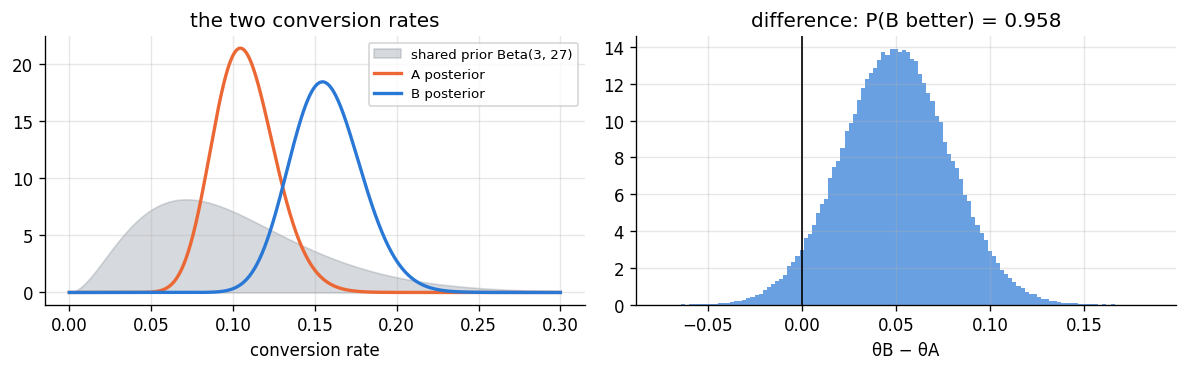

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(5)

a0, b0 = 3, 27
nA, yA = 240, 26
nB, yB = 250, 41
postA = stats.beta(a0 + yA, b0 + nA - yA)
postB = stats.beta(a0 + yB, b0 + nB - yB)

for name, p, yy, nn in [("A", postA, yA, nA), ("B", postB, yB, nB)]:
    lo, hi = p.ppf([0.025, 0.975])
    print(f"version {name}: observed {yy / nn:.3f}, posterior mean {p.mean():.3f}, 95% credible interval ({lo:.3f}, {hi:.3f})")

S = 200_000
tA, tB = postA.rvs(S, random_state=rng), postB.rvs(S, random_state=rng)
p_better = (tB > tA).mean()
exact = integrate.quad(lambda t: postA.pdf(t) * postB.sf(t), 0, 1)[0]   # P(θB > θA) = ∫ pA(t) P(θB > t) dt
print(f"\nP(θB > θA | data): Monte Carlo {p_better:.4f}, numerical integral {exact:.4f}")
lift = tB / tA - 1
print(f"relative lift of B: median {np.median(lift):+.0%}, 95% interval ({np.quantile(lift, 0.025):+.0%}, {np.quantile(lift, 0.975):+.0%})")
print(f"P(lift > 20%) = {(lift > 0.2).mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
t = np.linspace(0, 0.3, 600)
ax[0].fill_between(t, stats.beta.pdf(t, a0, b0), color=PRIOR, alpha=0.35, label="shared prior Beta(3, 27)")
ax[0].plot(t, postA.pdf(t), color=LIK, lw=2, label="A posterior")
ax[0].plot(t, postB.pdf(t), color=POST, lw=2, label="B posterior")
ax[0].set_xlabel("conversion rate"); ax[0].legend(fontsize=8); ax[0].set_title("the two conversion rates")
ax[1].hist(tB - tA, bins=120, density=True, color=POST, alpha=0.7)
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("θB − θA"); ax[1].set_title(f"difference: P(B better) = {p_better:.3f}")
plt.tight_layout(); plt.show()

This is the kind of answer decision-makers actually want: "B is better with
probability about 96%; the most likely lift is around +45%, but the data are still
compatible with anything from a small loss to more than doubling the conversion
rate." Compare it with a p-value, which
answers a different question (how surprising the data would be if A and B were
identical).

## 4. Predicting future successes

The posterior predictive for the number of successes $\tilde y$ in $m$ future trials
has a closed form here, the **beta-binomial distribution**:
$$ p(\tilde y\mid y) = \int_0^1 \binom{m}{\tilde y}\theta^{\tilde y}(1-\theta)^{m-\tilde y}\,
   \frac{\theta^{\alpha'-1}(1-\theta)^{\beta'-1}}{B(\alpha',\beta')}\,\mathrm d\theta
   = \binom{m}{\tilde y}\frac{B(\alpha'+\tilde y,\ \beta'+m-\tilde y)}{B(\alpha',\beta')}, $$
where $(\alpha',\beta')$ are the posterior parameters and $B$ is the beta function
$B(a,b) = \Gamma(a)\Gamma(b)/\Gamma(a+b)$. The integral is easy because the integrand
is an unnormalised beta density. scipy calls it `stats.betabinom`. We check it by
simulating: draw $\theta$ from the posterior, then $\tilde y$ from the binomial.

In [2]:
m = 100                                           # the next 100 visitors to version B
pred = stats.betabinom(m, a0 + yB, b0 + nB - yB)
sim = rng.binomial(m, postB.rvs(200_000, random_state=rng))
print(f"buyers among next {m} B visitors: formula mean {pred.mean():.2f} sd {pred.std():.2f} | "
      f"simulation mean {sim.mean():.2f} sd {sim.std():.2f}")
print(f"P(at least 20 buyers) = {pred.sf(19):.3f}")

buyers among next 100 B visitors: formula mean 15.71 sd 4.23 | simulation mean 15.73 sd 4.22
P(at least 20 buyers) = 0.183


## 5. The Poisson-gamma model

**Model.** Counts $y_1,\dots,y_n$ of events in equal time periods, occurring at an
unknown rate $\lambda$, with a Gamma prior (shape $\alpha$, rate $\beta$):
$$ y_i\mid\lambda \overset{\text{iid}}{\sim}\text{Poisson}(\lambda),\qquad \lambda\sim\text{Gamma}(\alpha,\beta). $$

**Posterior.** The likelihood is $\prod_i \lambda^{y_i}e^{-\lambda}/y_i! \propto \lambda^{\sum y_i}e^{-n\lambda}$, so
$$ p(\lambda\mid y) \propto \lambda^{\sum y_i}e^{-n\lambda}\cdot\lambda^{\alpha-1}e^{-\beta\lambda}
   = \lambda^{\alpha+\sum y_i-1}e^{-(\beta+n)\lambda}, $$
$$ \boxed{\;\lambda\mid y\sim\text{Gamma}\Big(\alpha+\sum_i y_i,\ \beta+n\Big)\;} $$
**Add the total count to the shape and the number of periods to the rate.** The
prior acts like $\beta$ earlier periods in which $\alpha$ events were seen in total,
and the posterior mean is again a weighted average:
$$ \mathbb E[\lambda\mid y] = \frac{\alpha+\sum y_i}{\beta+n}
   = \frac{\beta}{\beta+n}\cdot\frac{\alpha}{\beta} + \frac{n}{\beta+n}\cdot\bar y. $$

**Posterior predictive.** For a new count $\tilde y$ the predictive is a **negative
binomial**, $\tilde y\mid y\sim \text{NegBin}\big(\alpha',\ \beta'/(\beta'+1)\big)$ in
scipy's parameterisation, with $(\alpha', \beta')$ the posterior parameters. Its
variance exceeds its mean, unlike a Poisson, because it includes uncertainty about
$\lambda$.

**Example.** A café's owner records the number of customer complaints on each of
7 days: 6, 3, 7, 5, 8, 4, 6. From the chain's other cafés, the rate is typically
around 3 per day, and the owner encodes that as a Gamma$(6, 2)$ prior: mean 3, worth
2 days of data. The posterior is Gamma$(6+39,\ 2+7) = $ Gamma$(45, 9)$.

posterior Gamma(45, 9): mean 5.000 = 0.22 x prior mean 3.0 + 0.78 x sample mean 5.571
95% credible interval for λ: (3.65, 6.56) complaints per day
tomorrow: predictive mean 5.00, var 5.56 (a Poisson would have var = mean); simulated var 5.56
P(10 or more complaints tomorrow) = 0.0398


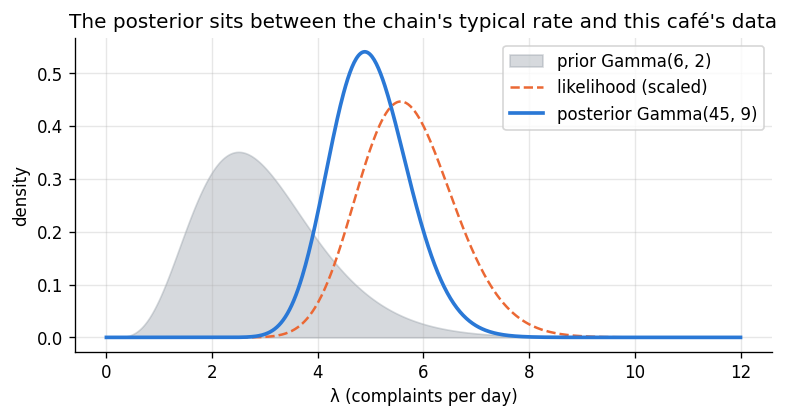

In [3]:
counts = np.array([6, 3, 7, 5, 8, 4, 6])
a0, b0 = 6.0, 2.0
a1, b1 = a0 + counts.sum(), b0 + len(counts)
post = stats.gamma(a=a1, scale=1 / b1)
w = b0 / (b0 + len(counts))
print(f"posterior Gamma({a1:.0f}, {b1:.0f}): mean {post.mean():.3f} = {w:.2f} x prior mean {a0 / b0:.1f} "
      f"+ {1 - w:.2f} x sample mean {counts.mean():.3f}")
lo, hi = post.ppf([0.025, 0.975])
print(f"95% credible interval for λ: ({lo:.2f}, {hi:.2f}) complaints per day")

pred = stats.nbinom(a1, b1 / (b1 + 1))
sim = rng.poisson(post.rvs(200_000, random_state=rng))
print(f"tomorrow: predictive mean {pred.mean():.2f}, var {pred.var():.2f} (a Poisson would have var = mean); "
      f"simulated var {sim.var():.2f}")
print(f"P(10 or more complaints tomorrow) = {pred.sf(9):.4f}")

lam = np.linspace(0, 12, 600)
plt.fill_between(lam, stats.gamma.pdf(lam, a0, scale=1 / b0), color=PRIOR, alpha=0.35, label="prior Gamma(6, 2)")
plt.plot(lam, stats.gamma.pdf(lam, counts.sum() + 1, scale=1 / len(counts)), color=LIK, lw=1.5, ls="--",
         label="likelihood (scaled)")
plt.plot(lam, post.pdf(lam), color=POST, lw=2.2, label=f"posterior Gamma({a1:.0f}, {b1:.0f})")
plt.xlabel("λ (complaints per day)"); plt.ylabel("density")
plt.title("The posterior sits between the chain's typical rate and this café's data")
plt.legend(); plt.show()

## 6. Choosing the hyperparameters

The effective-sample-size reading makes conjugate priors easy to set:

1. Choose a **prior mean** $m$ from background knowledge.
2. Choose how many observations the prior should be **worth**, $k$.
3. Solve: for a beta prior, $\alpha = mk$, $\beta = (1-m)k$; for a gamma prior on a
   Poisson rate, $\beta = k$ periods and $\alpha = mk$ events.

Always look at the prior you have chosen, for example with its central 95% interval
or its prior predictive distribution, and ask whether it says what you meant.
Chapter 07 returns to priors in more depth.

### Exercises

1. Show that the posterior mean of the beta-binomial model always lies between the
   prior mean and $y/n$.
2. In the A/B test, redo the analysis with flat Beta$(1,1)$ priors and with a strong
   Beta$(30, 270)$ prior. How do $P(\theta_B>\theta_A)$ and the lift interval change?
3. Derive $P(\theta_B > \theta_A)$ as a one-dimensional integral (as used in the code)
   and explain why it is correct.
4. For the café, the owner opens on an eighth day and gets 12 complaints. Update the
   posterior by adding one observation, and check that it matches refitting with all
   8 days.
5. Show that the negative binomial predictive has variance
   $\alpha'/\beta' + \alpha'/\beta'^2$, and interpret the two terms.
6. The Wald interval of chapter 03 failed when $y=0$. Compute the 95% equal-tailed
   credible interval under a Beta$(1/2, 1/2)$ prior for $y=0$, $n=20$. Then compute
   its frequentist coverage at $\theta=0.05$ with the `coverage` function of chapter 03.

## References

1. H. Raiffa, R. Schlaifer. *Applied Statistical Decision Theory.* Harvard University Press, 1961.
2. P. Diaconis, D. Ylvisaker. *Conjugate priors for exponential families.* The Annals of Statistics, 7(2):269-281, 1979. doi:10.1214/aos/1176344611
3. P. D. Hoff. *A First Course in Bayesian Statistical Methods.* Springer, 2009. (Chapter 3.)
4. A. Gelman et al. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013. (Chapter 2.)
5. W. M. Bolstad. *Introduction to Bayesian Statistics.* Wiley, 2004. (Chapters on the binomial and Poisson.)
6. D. Fink. *A Compendium of Conjugate Priors.* Technical report, Montana State University, 1997.